# CSSlib functionality demonstration

## Import of CSSlib library

In [1]:
# all important library features are available at the top level of the CSSlib
# therefore the following import will cover all nessesary functions which can be used
import csslib

# also the following import can be performed:
# from csslib import *

## Core functionality

All functions in the CSSlib have docstrings with detailed description of classes/methods/functions. Use print(`csslib.<function>.__doc__`) or print(`csslib.<class>.<method>.__doc__`) to find the detailed description.

The CSSlib main targer is a css space generation. Also it containes a set of classes for dataloading, local/remote MPI or SLURM calculations and data visualization. Current pipeline can be visualized as:

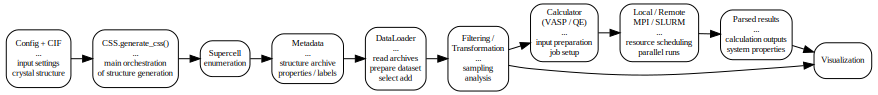

In [2]:
from graphviz import Digraph
from IPython.display import display

# Используем rankdir="LR" (слева направо) для экономии вертикального места
g = Digraph("CSSlib_pipeline")
g.attr(rankdir="LR", nodesep="0.2", ranksep="0.3", fontsize="10")

# Настраиваем общие параметры для всех узлов сразу
g.attr('node', shape='box', style='rounded', fontsize='9', margin='0.01')

g.node("A", "Config + CIF\n...\ninput settings\ncrystal structure", fixedsize='true', width='0.9', height='0.8', margin='0')
g.node("B", "CSS.generate_css()\n...\nmain orchestration\nof structure generation", fixedsize='true', width='1.2', height='0.8', margin='0')
g.node("C", "Supercell\nenumeration", fixedsize='true', width='0.7', height='0.5', margin='0')
g.node("D", "Metadata\n...\nstructure archive\nproperties / labels", fixedsize='true', width='1.0', height='0.7', margin='0')
g.node("E", "DataLoader\n...\nread archives\nprepare dataset\nselect add", fixedsize='true', width='0.85', height='0.88', margin='0')
g.node("F", "Filtering /\nTransformation\n...\nsampling\nanalysis", fixedsize='true', width='0.85', height='0.9', margin='0')
g.node("G", "Calculator\n(VASP / QE)\n...\ninput preparation\njob setup", fixedsize='true', width='0.95', height='0.8', margin='0')
g.node("H", "Local / Remote\nMPI / SLURM\n...\nresource scheduling\nparallel runs", fixedsize='true', width='1.1', height='0.8', margin='0')
g.node("I", "Parsed results\n...\ncalculation outputs\nsystem properties", fixedsize='true', width='1.0', height='0.7', margin='0')
g.node("J", "Visualization", fixedsize='true', width='0.8', height='0.5', margin='0')

# Соединения
g.edge("A", "B")
g.edge("B", "C")
g.edge("C", "D")
g.edge("D", "E")
g.edge("E", "F")
g.edge("F", "G")
g.edge("G", "H")
g.edge("H", "I")
g.edge("F", "J")
g.edge("I", "J")

display(g)


First and very useful class of the lib is CSS, which can generate configurational space using `supercell`. It requires `config_filename` argument with relative path to the `.json` config file.

All example configs for the css generation are located at `tests/data/`.

In this tutorial an example for $\mathrm{WSe}_2$ will be shown:

In [3]:
# css = csslib.CSS(r'data/WSe2/config_WSe2.json')

css = csslib.CSS(r'data/WSe2/config_WSe2.json', rewrite_results=True)

INFO - The following config is read:
Config(
  result_dir="WSe2",
  structure_filename="data/WSe2/WSe2.cif",
  supercell="2x2x1",
  num_workers=4,
  fictive_atoms=['U', 'Np'],
  substitution=[
    Substitution(
      specie_to_substitute="W",
      substitute_with="Mo",
      substitution_low_limit=0.0,
      substitution_high_limit=0.3333333,
    ),
    Substitution(
      specie_to_substitute="W",
      substitute_with="U",
      substitution_low_limit=0.0,
      substitution_high_limit=0.1666667,
    ),
    Substitution(
      specie_to_substitute="Se",
      substitute_with="S",
      substitution_low_limit=0.0,
      substitution_high_limit=0.6666667,
    ),
    Substitution(
      specie_to_substitute="Se",
      substitute_with="Np",
      substitution_low_limit=0.0,
      substitution_high_limit=0.3333333,
    )
  ]
)



After read of the config an output to the console will duplicate information about it. If `results` folder is already created than an exeption will occur. To avoid this mistake `rewrite_results` flag at the CSS initialization step can be used.

CSSlib has two helpful functions which will show available config fields to fill and an example config file:

In [4]:
csslib.get_available_config_fields()

INFO - 
List of available config fields:
  - "result_dir" - full or relative path to the results directory (mandatory)
  - "structure_filename" - full or relative path to the .cif initial structure file (mandatory)
  - "supercell" - system replication numbers in the following format: "2x1x1", "2x2x1", ... (optional, default value - "1x1x1")
  - "num_workers" - number of parallel processes (optional, default value - 1)
  - "fictive_atoms" - list with fictive atom names. Must be filled. If there are no one fictive atom type in the system fictive_atoms should be [] (mandatory)
  - "substitution" - list of required substitutions for the system (optional). The field has the following subfields:
    - "specie_to_substitute" - string with a chemical element which should be replaced (mandatory)
    - "substitute_with" - string with with a chemical element that will replace the original chemical element (mandatory)
    - "substitution_low_limit" - float value containing lower boundary of the su

In [5]:
csslib.get_example_config()

INFO - 
{
  "result_dir": "path-to-directory-with-results",
  "structure_filename": "path-to-cif-file",
  "supercell": "1x1x1",
  "num_workers":  1,
  "fictive_atoms": ['X', 'N'],
  "substitution": [
    {
      "specie_to_substitute": "X",
      "substitute_with": "Y",
      "substitution_low_limit": 0.0,
      "substitution_high_limit": 0.05
    },
    {
      "specie_to_substitute": "E",
      "substitute_with": "N",
      "substitution_low_limit": 0.0,
      "substitution_high_limit": 0.06
    }
  ]
}


The full css can be constructed by the one function call: 

In [58]:
css.generate_css()

INFO - Initial structure is read at data/WSe2/WSe2.cif.
INFO - Preparing to evaluate substitution parameters ...
INFO - Substitution parameters are evaluated successfully!
INFO - Substitution template is created and saved at results/WSe2/substitution_template_WSe2.cif.
INFO - Preparing to check out possibility of CSS structures creation ...


Checking out possibility of CSS structures creation:  91%|████████████████████████████████████████████████████████████████████████████████████████▏        | 382/420 [00:00<00:00, 850.69 composition/s]

INFO - Checking out possibility of CSS structures creation is finished successfully!


Checking out possibility of CSS structures creation: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 420/420 [00:00<00:00, 759.40 composition/s]

INFO - Preparing to generate CSS structures ...



Creating CSS structures: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 420/420 [00:05<00:00, 73.98 composition/s]

INFO - CSS structures are generated and saved at results/WSe2/css_structures.
INFO - Generation of CSS structures is finished successfully!
INFO - Preparing to collect metadata of CSS structures ...


INFO - Metadata of CSS structures is collected and saved at results/WSe2/css_structures_metadata.


All data from the supercell has been stored in `results/tests/WSe2/css_structures_metadata`. This folder consists of many `.pkl.gz` files which should be further parsed and used.

For this purpose DataLoader class was introduced. It can read one `.pkl.gz` file or iteratively collect the data from directory.

Below the __docstring__ for DataLoader initialization is presented:

In [6]:
print(csslib.DataLoader.__init__.__doc__)


            Initialization method for the DataLoader class.

            Args:
                path (str): path to folder/file with .pkl.gz archive/s with structures for loading/processing.
                num_workers (int, optional): number of workers for parallel execution of the DataLoader. Defaults to 1.
                transformation_function (Callable | None, optional): transformation function to be applied to the configurations set.
                As the input function must get pandas.Dataframe object and return transformed pandas.Dataframe object.
                Defaults to None.
                save_loaded_data (bool, optional): if True stores loaded data in the save_loaded_data_filepath.
                Uses only when path variable points on the directory. Otherwise, the flag is always changes to False. Defaults to True.
                save_loaded_data_path (str, optional): path to the file where loaded data will be stored. Defaults to '<path>/selected.pkl.gz'.
          

Let's initialize dataloader to get an information about space-group distribution in the dataset:

In [61]:
space_distr = csslib.DataLoader(
    path='results/WSe2/css_structures_metadata',
    num_workers=4,
    transformation_function=csslib.get_spacegroup_distribution,
    save_loaded_data=False,
    copy_unloaded_data=False,
)

Transformation function for the `DataLoader` can be any function which will get `pandas.DataFrame` object and return its transformed version.

If function requires any additional arguments, then `csslib.load_function` can be used. It ignores first argument of all functions, cause it must be `pandas.DataFrame` object and can get positional or named argumets. An example with `csslib.load_function` will be shown further.

Now lets check the dataframe obtained:

In [64]:
print(space_distr.get_df())

      space_group_no space_group_symbol  Mo_concentration  S_concentration  \
0                  1                 P1          0.083333         0.500000   
1                  5                 C2          0.083333         0.500000   
2                  6                 Pm          0.083333         0.500000   
3                  8                 Cm          0.083333         0.500000   
4                 38               Amm2          0.083333         0.500000   
...              ...                ...               ...              ...   
1224               6                 Pm          0.000000         0.166667   
1225               7                 Pc          0.000000         0.166667   
1226               8                 Cm          0.000000         0.166667   
1227              38               Amm2          0.000000         0.166667   
1228              39               Aem2          0.000000         0.166667   

      Se_concentration  W_concentration  cfgs_count  all_cfgs_c

For the best representation of the data, lets plot it using internal visualization function:

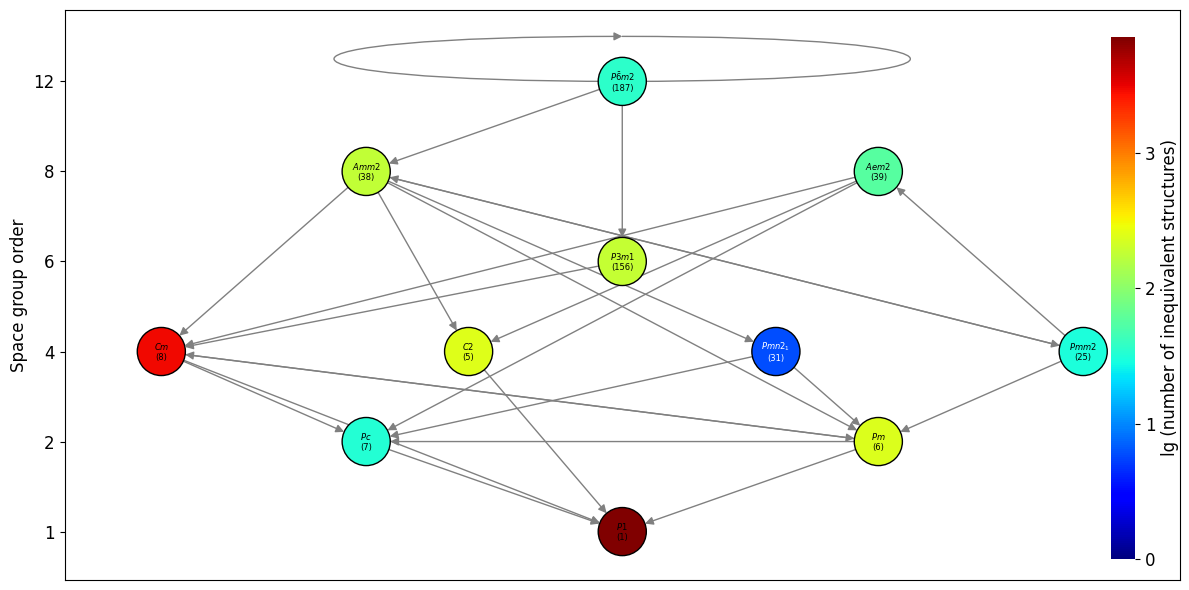

In [66]:
csslib.group_subgroup_diagram(
    css_df=space_distr,
    figsize=(12,6),
    cmap='jet'
)

The second case (and primary), where DataLoader can be used is for GNN training set formation. For this purpose, lets create a new DataLoader: 

In [7]:
data = csslib.DataLoader(
    path='results/WSe2/css_structures_metadata',
    num_workers=4,
    transformation_function=csslib.load_function(csslib.random_sampling, structures_number=3, seed=12345)
)

DataLoader iteratively collects data from each `.pkl.gz` applying for it `csslib.random_sampling` function and forms a unified dataset. All selected structures by default are placed at selected.pkl.gz for further convinient use. All unselected structures by default are placed at the `css_unselected` folder.

Lets check how much configurations were selected:

In [8]:
print(len(data))

1168


It should be also noticed, that `csslib` contains function for split data by the spacegroup number:

In [9]:
print(csslib.split_by_spacegroup.__doc__)


        Splits the dataset with configurations by spacegroup number. Selects only configurations that has
        a number more than/lower than the specified value. It is convinient to use load_function for preinitialization.

        Args:
            df (pandas.DataFrame): dataframe with structures to select.
            space_group_no (int): space group number.
            greater_than_or_equal_to (bool, optional): if True selects only configurations with a spacegroup
            number greater than or equal to space_group_no. If False selects lower than or equal to 
            space_group_no. Defaults to True.

        Return:
            pandas.DataFrame: dataframe with selected structures.
    


Also DataLoader has a `select_add` method, which can be used in active learning procedures (`select_add` can get a new transformation_function for the selection). It reads configurations from the full set of configurations or from `css_unselected` (and deletes selected structures from it):

In [10]:
print(data.select_add.__doc__)


            Additionaly selects and adds configurations to the df attribute. Can be used in the active learning procedure.

            Args:
                select_path (str | None, optional): path to the folder with .pkl.gz files from which configurations will be selected.
                Can be empty if path parameter in __init__ method was a path to the directory. Defaults to None.
                transformation_function (Callable | None, optional): transformation function to be applied to the loaded data.
                Can be empty if transformation_function attribute was already setup by other methods. Defaults to None.
                save_merged_df_to (str | None, optional): path to the .pkl.gz file in which dataset will be saved. Defaults to None.

            Raise:
                csslib.exceptions.DataLoaderError: if unselected configuration were not saved earlier and select_path parameter is None or
                transformation_function attribute is None and transform

In [11]:
data.select_add(
    transformation_function=csslib.load_function(csslib.split_by_spacegroup, space_group_no=80),
    save_merged_df_to='results/WSe2/selected_it2.pkl.gz'
)

Now the dataset will have:

In [12]:
print(len(data))

1294


+126 configurations.

DataLoader also has some magic methods implemented for the user convivnient use. They are: `__getitem__` (returns a pandas.Series column object from the dataset):

In [13]:
print(data['space_group_no'])

0         8
1         1
2        38
3         1
4         1
       ... 
1289    156
1290    156
1291    156
1292    156
1293    156
Name: space_group_no, Length: 1294, dtype: int64


`__setitem__`:

In [14]:
# data['some_column'] = value

`__iter__`:

In [15]:
for row in data:
    print(row.composition)
    break

U1 Mo1 W2 Se2 S6


`__getattr__` (returns attributes from the `pandas.DataFrame` object):

In [16]:
print(data.columns, data.index, sep='\n')

Index(['cif_data', 'structure_filename', 'composition', 'space_group_no',
       'space_group_symbol', 'weight', 'Mo_concentration',
       'Np_concentration (fictive)', 'S_concentration', 'Se_concentration',
       'U_concentration (fictive)', 'W_concentration'],
      dtype='object')
RangeIndex(start=0, stop=1294, step=1)


`__repr__` (prints `pandas.DataFrame.describe()` result):

In [17]:
print(data)

DataLoader object located at 0x7a5d56c3eed0. Stores the pandas.DataFrame object with the following statistics:
       space_group_no       weight  Mo_concentration  \
count     1294.000000  1294.000000       1294.000000   
mean        33.500773    29.035549          0.133758   
std         58.912427    16.080625          0.106333   
min          1.000000     1.000000          0.000000   
25%          1.000000    12.000000          0.000000   
50%          8.000000    24.000000          0.125000   
75%          8.000000    48.000000          0.250000   
max        187.000000    48.000000          0.333333   

       Np_concentration (fictive)  S_concentration  Se_concentration  \
count                 1294.000000      1294.000000       1294.000000   
mean                     0.157200         0.255345          0.254122   
std                      0.115836         0.168073          0.168284   
min                      0.000000         0.000000          0.000000   
25%                     

DataLoader with the selected data should be further used for DFT or UMLIP calculations. For this purpose the `Calculator` base class was implemented. It has two preinitialized subclasses such as `VaspCalculator` and `EspressoCalculator`. For this tutorial purposes we will use the `VaspCalculator` (Also it is very useful to check the `Calculator` class):

In [18]:
print(csslib.VaspCalculator.__init__.__doc__)


            Initializes a partially preconfigured VASP calculator instance.

            Args:
                data (str | DataLoader): path to the dataset or initialized DataLoader object.
                cmd (MPI | SLURM | list[MPI] | list[SLURM]): command or commands used for VASP execution.
                remote_path (str): root directory where calculation work folders will be created.
                local_path (str | None, optional): local directory for copied calculation outputs. Defaults to None.
                input_paths (str | os.PathLike | list[str | os.PathLike] | None, optional): path or paths to static VASP input templates. Defaults to None.
                inputs (VaspInputs | None, optional): preconfigured VaspInputs object. Defaults to None.
                parser (Callable | None, optional): custom VASP result parser. Defaults to None.
                loading_files (list[str] | None, optional): files that should be copied after calculation. Defaults to None.
     

As can be seen from the detailed description, `Calculator` can obtain data as `string path` or `DataLoader` object. Also it requires a cmd. Cmd is an object which contain settings for local or remote calculations. It can be `MPI` or `SLURM`:

In [19]:
mpi_cmd = csslib.MPI(
    prefix="mpirun",
    cores_number=16,
    binary="vasp_std"
)

slurm_cmd = csslib.SLURM(
    partition='small',
    binary='vasp_std',
    nodes=1,
    ntasks=16,
    exclude="node_[103,104]"
)

Full list of fields can be obtained from:

In [22]:
print("MPI:\n" + csslib.MPI.__doc__, "SLURM:\n" + csslib.SLURM.__doc__, sep='\n\n')

MPI:

        Dataclass with data for the calculation start.
        
        Attributes:
            prefix (str, optional): type of the mpi binary to execute. Defaults to mpirun.
            cores_number (int | None, optional): number of cores to use. Defaults to None, e.g. all cores are used.
            binary (str | None, optional): name of the binary file to be used. If None the error will be raised. Defaults to None.
            output (str, optional): name of the output file. Defaults to ".csslib.stdout".
            error (str, optional): name of the stderr file. Defaults to ".csslib.stderr".
    

SLURM:

        Dataclass with data for the calculation start.
        
        Attributes:
            prefix (str, optional): type of the slurm command to execute. Defaults to sbatch.
            partition (str): name of the partition to be used. Must be non-empty for the resources distribution. Defaults to None. MUST BE FILLED.
            mpitype (str, optional): name of the mpi

In the common case `VaspCalculator` can be initialized as:

In [ ]:
calc = csslib.VaspCalculator(
    data=data, 
    cmd=slurm_cmd, 
    remote_path='/home/user/folder', 
    input_paths='/path/.../.../inputs', 
    assemble_potcar=True, 
    potcar_dir="/home/user/potcats/PAW_PBE", 
    server_ip='192.168.17.101', 
    username='user', 
    port=44444, 
    password='password'
)

Instead of password it is recomended to use `host_keys_path` argument to load host keys for the remote connection. Also `dotenv` libriary can be used.

One of the interesting features of `csslib` is an opportunity to create a lot of connections for different servers and make calculations on the local machine (cmd for the local machine should be placed at the end of the list):

In [ ]:
# calc = csslib.VaspCalculator(
#     data=data, 
#     cmd=[slurm_cmd, slurm_cmd_2, mpi_cmd, ..., local_cmd], 
#     remote_path='/home/user/folder', 
#     input_paths='/path/.../.../inputs', 
#     parser=custom_parser_function
#     assemble_potcar=True, 
#     potcar_dir="/home/user/potcats/PAW_PBE", 
#     server_ip=['192.168.17.101', '192.168.17.201, '192.168.17.301', ...], 
#     username=['user', 'dave', 'man', ...], 
#     port=[44444, 22, 22, ...], 
#     password=['password', 'password2', ...],
#     use_local=True,
#     use_sftp=True
# )

When calculator is initialized, then the `run` method should be started:

In [ ]:
calc.run()

After end of calculations, the dataframe will have +3 columns which were used by calculator. One of them is the `calculation_output`. Lets load the prepared dataset and check its results field:

In [26]:
calculated = csslib.DataLoader(
    path='calculated.pkl.gz'
)

In [27]:
calculated.calculation_output

0     <pymatgen.io.vasp.outputs.Vasprun object at 0x...
1     <pymatgen.io.vasp.outputs.Vasprun object at 0x...
2     <pymatgen.io.vasp.outputs.Vasprun object at 0x...
3     <pymatgen.io.vasp.outputs.Vasprun object at 0x...
4     <pymatgen.io.vasp.outputs.Vasprun object at 0x...
5     <pymatgen.io.vasp.outputs.Vasprun object at 0x...
6     <pymatgen.io.vasp.outputs.Vasprun object at 0x...
7     <pymatgen.io.vasp.outputs.Vasprun object at 0x...
8     <pymatgen.io.vasp.outputs.Vasprun object at 0x...
9     <pymatgen.io.vasp.outputs.Vasprun object at 0x...
10    <pymatgen.io.vasp.outputs.Vasprun object at 0x...
11    <pymatgen.io.vasp.outputs.Vasprun object at 0x...
12    <pymatgen.io.vasp.outputs.Vasprun object at 0x...
13    <pymatgen.io.vasp.outputs.Vasprun object at 0x...
14    <pymatgen.io.vasp.outputs.Vasprun object at 0x...
15    <pymatgen.io.vasp.outputs.Vasprun object at 0x...
16    <pymatgen.io.vasp.outputs.Vasprun object at 0x...
17    <pymatgen.io.vasp.outputs.Vasprun object a

In [35]:
calculated.calculation_output[0].final_energy

-58.44971058

Calculation output contains object parsed by the default csslib parser (it is `pymatgen.io.vasp.Vasprun`). From this objects all the data required can be obtained. If you wish to use another parser, you can write your own custom parser.